# 06C — Base Marketing Mix Model (MMM)

---

## What is this notebook?

- This is the **base model** — a simplified, clean starting point for measuring how media spending impacts Club Piscine's revenue
- It's intentionally minimal: we want to understand the fundamentals before adding complexity
- Every cell does one thing and is explained in plain language so we can walk through it together with the client

## What does the model do?

- **Step 1**: Separate out the seasonal pattern (pools sell in summer — that's not because of advertising)
- **Step 2**: Measure what's left over and ask: how much of that is explained by media spending?
- The result: a ROAS (Return on Ad Spend) estimate for each of the 7 media channels, plus confidence intervals telling us how sure we are

## Structure (each cell = one step)

- **Cells 1–2**: Load data and calibrated parameters from NB05
- **Cells 3–4**: Transform the spend data (adstock = carryover over time, saturation = diminishing returns)
- **Cell 5**: Build the feature matrices for both stages
- **Cell 6**: Stage 1 — fit the seasonal baseline
- **Cell 7**: Stage 2 — fit media effects on the residuals (Ridge regression)
- **Cell 8**: Convert coefficients to ROAS and media contribution %
- **Cell 9**: Bootstrap confidence intervals (how reliable are these numbers?)
- **Cell 10**: Diagnostics
- **Cells 11–12**: Final summary, export, and charts

## Key decisions in this base model

- **Parameters loaded from NB05** — decay rates from multi-channel grid search (16,384 combos), saturation functions selected per-channel by LOOCV (Hill, Log, or Power)
- **No forced non-negativity** — if a channel shows a negative coefficient, we want to see it honestly rather than masking it
- **Ridge regression** — prevents overfitting given we only have 36 months of data
- **Mixed saturation functions** — each channel uses the function that fit best in NB05 (Hill, Log, or Power), rather than forcing one function for all


---
## Cell 1 — Load the Data

- We're loading the merged dataset that was built in earlier notebooks (NB01–05)
- It contains 36 monthly rows (3 fiscal years: FY2023–FY2025), with revenue, media spend by channel, and weather data
- This is the same data used in NB06 and NB06B — nothing new here, just loading it cleanly

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats

# Import transformation functions (single source of truth)
import sys
sys.path.append(str(Path('.').resolve().parent))
from src.features.transformations import (
    geometric_adstock,
    hill_saturation,
    log_saturation,
    power_saturation,
    calculate_half_life,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# --- Paths ---
project_root = Path('.').resolve().parent
data_dir = project_root / 'data' / 'processed'
fig_dir = project_root / 'reports' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# --- Load the merged dataset (sales + spend + weather, 36 rows × 43 cols) ---
df = pd.read_csv(data_dir / 'sales_spend_weather.csv')
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total revenue (3Y): ${df['total_all_revenue'].sum():,.0f}")
print(f"Total media spend (3Y): ${df['spend_total'].sum():,.0f}")
df.head(3)


Dataset: 36 rows × 43 columns
Date range: 2022-11-01 to 2025-10-01
Total revenue (3Y): $512,411,602
Total media spend (3Y): $9,412,690


,year,month_num,piscines_hors_terre_units,piscines_hors_terre_revenue,piscines_creusees_units,piscines_creusees_revenue,spas_units,spas_revenue,meubles_gazebo_revenue,fitness_revenue,...,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2023,11,118,580442,12,348768,134.0,1442912,722398.0,334203.0,...,418.8,0.0,1.04,0,0,0,0,0,0,0
1,2023,12,66,324654,6,174384,62.0,667616,315901.0,308733.0,...,619.9,0.0,-2.00,2,0,1,0,0,0,0
2,2023,1,308,1515052,18,523152,118.0,1270624,748026.0,752187.0,...,720.8,0.0,-8.90,2,0,1,0,0,0,0


---
## Cell 2 — Load Calibrated Parameters from NB05

All transformation parameters (adstock decay rates, saturation functions, K values) were calibrated in **Notebook 05** using:
- **Single-channel LOOCV grid search** — one channel at a time
- **Multi-channel joint grid search** — 16,384 combinations, literature-justified ranges
- **Sensitivity analysis** — robustness classification per channel
- **Saturation comparison** — Hill vs Log vs Power per channel
- **Bootstrap confidence intervals** — 200 resamples

The calibrated parameters are loaded from `optimal_transformation_params.json`. This notebook focuses solely on **model estimation**: fitting the two-stage Ridge regression, computing ROAS, and quantifying uncertainty.

### What's loaded:
- **Decay rates** — from multi-channel grid search (joint optimization)
- **Saturation functions** — mixed: Hill, Log, or Power per channel (data-selected)
- **Saturation parameters** — K/scale/beta per channel
- **Channel definitions** — 7 media channels with display labels


In [69]:
import json as _json

# ============================================================
# LOAD CALIBRATED PARAMETERS FROM NB05
# ============================================================
params_path = data_dir / 'optimal_transformation_params.json'
with open(params_path) as f:
    calib = _json.load(f)

print(f"Loaded parameters from: {params_path}")
print(f"Calibration date: {calib['calibration_date']}")
print(f"Method: {calib['calibration_method']}")
print(f"Grid search R²: {calib['grid_search_best_r2']}")

# ============================================================
# TARGET VARIABLE
# ============================================================
TARGET = calib['target']  # 'total_all_revenue'

# ============================================================
# 7 MEDIA CHANNELS — translate media_* keys to spend_* columns
# ============================================================
# NB05 uses media_* naming internally; the CSV has spend_* columns.
# The JSON provides a mapping to translate.
SPEND_COL_MAP = calib['spend_column_map']  # {media_*: spend_*}
MEDIA_KEYS = list(calib['decay_rates'].keys())  # media_* keys
CHANNELS = [SPEND_COL_MAP[mk] for mk in MEDIA_KEYS]  # spend_* columns

# Build label map: spend_* -> display name
CHANNEL_LABELS = {}
for mk in MEDIA_KEYS:
    spend_col = SPEND_COL_MAP[mk]
    CHANNEL_LABELS[spend_col] = calib['channel_labels'][mk]

# ============================================================
# ADSTOCK DECAY RATES (λ) — from multi-channel grid search
# ============================================================
DECAY_RATES = {}
for mk in MEDIA_KEYS:
    spend_col = SPEND_COL_MAP[mk]
    DECAY_RATES[spend_col] = calib['decay_rates'][mk]

# ============================================================
# SATURATION PARAMETERS — mixed functions from NB05
# ============================================================
SATURATION_FUNCS = {}  # {spend_col: 'hill'|'log'|'power'}
SATURATION_PARAMS = {}  # {spend_col: {K, alpha} or {scale} or {beta}}
for mk in MEDIA_KEYS:
    spend_col = SPEND_COL_MAP[mk]
    SATURATION_FUNCS[spend_col] = calib['saturation_functions'][mk]
    SATURATION_PARAMS[spend_col] = calib['saturation_params'][mk]

# ============================================================
# SENSITIVITY CLASSIFICATION (from NB05)
# ============================================================
SENSITIVITY = {}
for mk in MEDIA_KEYS:
    spend_col = SPEND_COL_MAP[mk]
    SENSITIVITY[spend_col] = calib.get('sensitivity_classification', {}).get(mk, 'UNKNOWN')

# ============================================================
# SEASONALITY CONTROLS (Fourier terms)
# ============================================================
FOURIER_ORDER = 1

# ============================================================
# WEATHER CONTROLS
# ============================================================
WEATHER_FEATURES = ['avg_temp_mean', 'total_precipitation']

# ============================================================
# BOOTSTRAP PARAMETERS (model-fitting, not calibration)
# ============================================================
N_BOOT = 1000
BLOCK_SIZE = 3

# ============================================================
# PRINT SUMMARY
# ============================================================
print()
print("=" * 70)
print("MODEL PARAMETERS (loaded from NB05 calibration)")
print("=" * 70)
print(f"Target: {TARGET}")
print(f"Channels: {len(CHANNELS)}")
print(f"Seasonality: Fourier order {FOURIER_ORDER} ({FOURIER_ORDER * 2} terms)")
print(f"Weather controls: {WEATHER_FEATURES}")
print()
print(f"{'Channel':<22} {'λ':>5} {'Half-life':>10} {'Saturation':>12} {'Sensitivity':>12}")
print("-" * 65)
for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    lam = DECAY_RATES[ch]
    hl = np.log(0.5) / np.log(lam) if 0 < lam < 1 else 0
    sat_func = SATURATION_FUNCS[ch]
    sens = SENSITIVITY.get(ch, '')
    print(f"  {label:<20s}  {lam:.2f}  {hl:>7.1f}mo  {sat_func:>12s}  {sens:>12s}")


MODEL PARAMETERS (Grid-Optimized Decay Rates)
Target: total_all_revenue
Channels: 7
Seasonality: Fourier order 1 (2 terms)
Weather controls: ['avg_temp_mean', 'total_precipitation']
Saturation: Hill (α=2), K = 70% of max adstocked spend

  Television            λ=0.10  half-life=0.3 months
  Radio                 λ=0.20  half-life=0.4 months
  Panneaux (DOOH)       λ=0.01  half-life=0.2 months
  Social Media          λ=0.01  half-life=0.2 months
  Preroll (Video)       λ=0.10  half-life=0.3 months
  Web Banners           λ=0.01  half-life=0.2 months
  Digital Flyers        λ=0.01  half-life=0.2 months


---
## Cell 3 — Adstock (Carryover Effect)

- Advertising doesn't just work the day it airs — a TV ad in March still has some effect in April
- Adstock models this: each month's spend gets "carried over" into the next month, but smaller each time
- The decay rate (λ) controls how fast it fades: λ=0.5 means 50% carries over, λ=0.1 means only 10%
- Formula: `Adstock_this_month = Spend_this_month + λ × Adstock_last_month`
- Below we show a before/after example for TV so you can see it in action

In [70]:
# Apply adstock to each channel using imported function
# (geometric_adstock from src/features/transformations.py)
for ch in CHANNELS:
    lam = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].fillna(0).values, lam)

# ============================================================
# Show before/after for ALL channels (first 6 months of FY2023)
# ============================================================
print("ADSTOCK TRANSFORMATION — ALL CHANNELS")
print("First 6 months of FY2023 (Nov 2022 – Apr 2023)")
print("=" * 75)

for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    lam = DECAY_RATES[ch]
    hl = np.log(0.5) / np.log(lam) if 0 < lam < 1 else 0

    print(f"\n--- {label} (λ={lam:.2f}, half-life={hl:.1f} months) ---")
    print(f"  {'Month':<12} {'Raw Spend':>12} {'Adstocked':>12} {'Δ':>10}")
    print(f"  {'-'*48}")

    for i in range(6):
        m = df.iloc[i]['month']
        raw = df.iloc[i][ch]
        ads = df.iloc[i][f'{ch}_adstock']
        diff = ads - raw
        print(f"  {m:<12} ${raw:>11,.0f} ${ads:>11,.0f} ${diff:>9,.0f}")

    raw_total = df[ch].sum()
    ads_total = df[f'{ch}_adstock'].sum()
    pct_change = (ads_total - raw_total) / raw_total * 100 if raw_total > 0 else 0
    print(f"  {'3Y Total':<12} ${raw_total:>11,.0f} ${ads_total:>11,.0f} ({pct_change:+.1f}%)")

# Overall summary table
print(f"\n\n{'='*75}")
print(f"ADSTOCK IMPACT SUMMARY")
print(f"{'='*75}")
print(f"{'Channel':<22} {'λ':>6} {'Raw 3Y ($K)':>13} {'Adstocked ($K)':>15} {'Change':>8}")
print("-" * 68)
for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    lam = DECAY_RATES[ch]
    raw_t = df[ch].sum()
    ads_t = df[f'{ch}_adstock'].sum()
    pct = (ads_t - raw_t) / raw_t * 100 if raw_t > 0 else 0
    print(f"{label:<22} {lam:>6.2f} {raw_t/1e3:>13,.0f} {ads_t/1e3:>15,.0f} {pct:>+7.1f}%")


ADSTOCK TRANSFORMATION — ALL CHANNELS
First 6 months of FY2023 (Nov 2022 – Apr 2023)

--- Television (λ=0.10, half-life=0.3 months) ---
  Month           Raw Spend    Adstocked          Δ
  ------------------------------------------------
  Novembre     $          0 $          0 $        0
  Décembre     $          0 $          0 $        0
  Janvier      $          0 $          0 $        0
  Février      $    147,872 $    147,872 $        0
  Mars         $    184,066 $    198,853 $   14,787
  Avril        $    368,584 $    388,470 $   19,885
  3Y Total     $  3,948,951 $  4,386,151 (+11.1%)

--- Radio (λ=0.20, half-life=0.4 months) ---
  Month           Raw Spend    Adstocked          Δ
  ------------------------------------------------
  Novembre     $          0 $          0 $        0
  Décembre     $          0 $          0 $        0
  Janvier      $     35,741 $     35,741 $        0
  Février      $     75,677 $     82,825 $    7,148
  Mars         $          0 $     16,565 $

---
## Cell 4 — Saturation (Diminishing Returns)

- Spending $50K on TV gets you a lot of awareness. Spending another $50K on top of that? Less additional impact. That's diminishing returns
- The Hill function models this: it takes the adstocked spend and squishes it into a 0-to-1 scale
- **K** = the half-saturation point. When spend hits K, you're at 50% of the maximum possible effect. We set K at 70% of each channel's peak observed spend
- **α = 2** = the steepness of the curve (standard value, same for all channels to keep things simple)
- This is the industry-standard approach used in most MMMs

In [71]:
# ============================================================
# APPLY SATURATION — mixed functions from NB05 calibration
# ============================================================
# Each channel uses the saturation function that maximized
# LOOCV R² in NB05 (Hill, Log, or Power).

K_VALUES = {}  # Store effective K/scale/beta for display

for ch in CHANNELS:
    adstock_col = f'{ch}_adstock'
    func = SATURATION_FUNCS[ch]
    params = SATURATION_PARAMS[ch]

    if func == 'hill':
        K = params['K']
        alpha = params.get('alpha', 2)
        K_VALUES[ch] = K
        df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, alpha)
    elif func == 'log':
        scale = params['scale']
        K_VALUES[ch] = scale
        df[f'{ch}_saturated'] = log_saturation(df[adstock_col].values, scale)
    elif func == 'power':
        beta = params['beta']
        K_VALUES[ch] = beta
        df[f'{ch}_saturated'] = power_saturation(df[adstock_col].values, beta)
    else:
        raise ValueError(f"Unknown saturation function '{func}' for {ch}")

# ============================================================
# Show the full picture: Raw → Adstocked → Saturated
# ============================================================
print("SATURATION TRANSFORMATION — MIXED FUNCTIONS (from NB05)")
print("=" * 85)
print()
print("Each channel uses the best saturation function selected by LOOCV in NB05:")
print("  Hill: y = x^α / (x^α + K^α)  →  output in [0, 1]")
print("  Log:  y = log(1 + x/scale)    →  unbounded, diminishing")
print("  Power: y = x^β (β<1)          →  unbounded, diminishing")
print()

# Summary table
print(f"{'Channel':<22} {'Function':>10} {'Param':>12} {'Max Adstock ($)':>16} {'Max Sat':>10} {'Avg Sat':>10}")
print("-" * 84)
for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    func = SATURATION_FUNCS[ch]
    max_ads = df[f'{ch}_adstock'].max()
    max_sat = df[f'{ch}_saturated'].max()
    avg_sat = df[f'{ch}_saturated'].mean()
    kv = K_VALUES[ch]

    if func == 'hill':
        param_str = f'K=${kv:,.0f}'
    elif func == 'log':
        param_str = f'scale=${kv:,.0f}'
    else:
        param_str = f'β={kv:.2f}'

    print(f"{label:<22} {func:>10} {param_str:>12} ${max_ads:>15,.0f} {max_sat:>10.3f} {avg_sat:>10.3f}")

# Detailed per-channel: first 12 months
print(f"\n\n{'='*85}")
print("DETAILED: First 12 months (FY2023) — Raw → Adstocked → Saturated")
print(f"{'='*85}")

for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    func = SATURATION_FUNCS[ch]
    lam = DECAY_RATES[ch]

    print(f"\n--- {label} (λ={lam:.2f}, {func}) ---")
    print(f"  {'Month':<12} {'Raw ($)':>12} {'Adstocked ($)':>14} {'Saturated':>10}")
    print(f"  {'-'*52}")

    for i in range(min(12, len(df))):
        m = df.iloc[i]['month']
        raw = df.iloc[i][ch]
        ads = df.iloc[i][f'{ch}_adstock']
        sat = df.iloc[i][f'{ch}_saturated']
        print(f"  {m:<12} ${raw:>11,.0f} ${ads:>13,.0f} {sat:>10.3f}")


SATURATION TRANSFORMATION — ALL CHANNELS

The Hill function maps adstocked spend to a 0–1 scale:
  0.0 = no effect, 1.0 = maximum possible effect
  At K (half-saturation), you're at 0.50 = halfway to the ceiling

Channel                     K ($)  Max Adstock ($)  Max Sat  Avg Sat
--------------------------------------------------------------------
Television             $  337,615 $        482,307     0.67     0.15
Radio                  $  131,880 $        188,401     0.67     0.26
Panneaux (DOOH)        $   54,736 $         78,194     0.67     0.06
Social Media           $   34,452 $         49,217     0.67     0.30
Preroll (Video)        $   47,998 $         68,569     0.67     0.26
Web Banners            $   49,654 $         70,934     0.67     0.19
Digital Flyers         $   28,280 $         40,400     0.67     0.20


DETAILED: First 12 months (FY2023) — Raw → Adstocked → Saturated

--- Television (λ=0.10, K=$337,615) ---
  Month             Raw ($)  Adstocked ($)  Saturated     

---
## Cell 5 — Build the Two Feature Sets

We split the model into two stages, so we need two sets of features:

- **Stage 1** (seasonality baseline): Fourier terms + weather **deviations**
  - Weather uses deviations from monthly norms (not raw values) to avoid multicollinearity with Fourier terms
  - This captures "was this month unusually warm/cold?" rather than "is it summer?"
- **Stage 2** (media effects): The 7 saturated media channels

The two-stage split is based on the Frisch-Waugh-Lovell theorem: regressing Y on [X1, X2] gives the same β₂ as regressing the residuals of Y~X1 on the residuals of X2~X1.

In [72]:
# --- Target ---
y = df[TARGET].values
n = len(y)

# --- Stage 1: Seasonality + Weather ---
# Fourier terms for annual seasonality
t = np.arange(n)
period = 12  # 12 months = 1 year

X1_dict = {}
for k in range(1, FOURIER_ORDER + 1):
    X1_dict[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
    X1_dict[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)

# Weather DEVIATIONS from monthly norms
# ============================================================
# FIX: Raw weather (avg_temp_mean) is highly correlated with
# Fourier cos_1 (VIF ~30), because both capture the annual
# temperature cycle. Using deviations isolates the ANOMALOUS
# weather signal — "was this March unusually warm?" — which is
# orthogonal to the regular seasonal pattern.
#
# This approach was already used in NB05 (Feature Engineering)
# but was inadvertently reverted to raw values in this notebook.
# ============================================================
for wf in WEATHER_FEATURES:
    monthly_mean = df.groupby('month_num')[wf].transform('mean')
    monthly_std = df.groupby('month_num')[wf].transform('std')
    # Standardized deviation: (observed - monthly_mean) / std
    # Handles months with zero std (constant weather) gracefully
    dev = (df[wf].values - monthly_mean.values)
    std_vals = monthly_std.values
    std_vals[std_vals == 0] = 1.0  # avoid division by zero
    X1_dict[f'{wf}_dev'] = dev / std_vals

X1 = pd.DataFrame(X1_dict)

# --- Stage 2: Media (saturated) ---
media_cols = [f'{ch}_saturated' for ch in CHANNELS]
X2 = df[media_cols].copy()
X2.columns = [CHANNEL_LABELS[ch] for ch in CHANNELS]  # Readable names

print(f"Stage 1 features ({X1.shape[1]}): {list(X1.columns)}")
print(f"Stage 2 features ({X2.shape[1]}): {list(X2.columns)}")
print(f"Target: {TARGET} (n={n})")
print(f"\nNote: Weather features are DEVIATIONS from monthly norms,")
print(f"not raw values. This eliminates VIF inflation with Fourier terms.")
print(f"\nTotal parameters to estimate: {X1.shape[1] + X2.shape[1] + 2} (incl. 2 intercepts)")
print(f"Observations-to-parameter ratio: {n / (X1.shape[1] + X2.shape[1] + 2):.1f}:1")

Stage 1 features (4): ['sin_1', 'cos_1', 'avg_temp_mean', 'total_precipitation']
Stage 2 features (7): ['Television', 'Radio', 'Panneaux (DOOH)', 'Social Media', 'Preroll (Video)', 'Web Banners', 'Digital Flyers']
Target: total_all_revenue (n=36)

Total parameters to estimate: 13 (incl. 2 intercepts)
Observations-to-parameter ratio: 2.8:1


---
## Cell 6 — Stage 1: Remove the Seasonal Pattern

This is the critical first step, and here's why:

- The media budget also peaks in summer (you advertise when people are buying)
- If we don't separate these two, the model would give media credit for summer demand that would have happened anyway
- So we first fit a simple model that captures the seasonal pattern + weather, then look at the **residuals**, the revenue that season and weather can't explain
- Those residuals are what media needs to account for
- The chart below shows: left = how well the seasonal model fits, right = the residuals (gaps the model doesn't explain)

Stage 1 — Seasonality Baseline
  R² = 0.849  (84.9% of revenue variance explained by season + weather)
  Residual std = $3,696,812/month
  Mean revenue = $14,233,656/month
  Residuals represent the 15.1% that media channels need to explain.


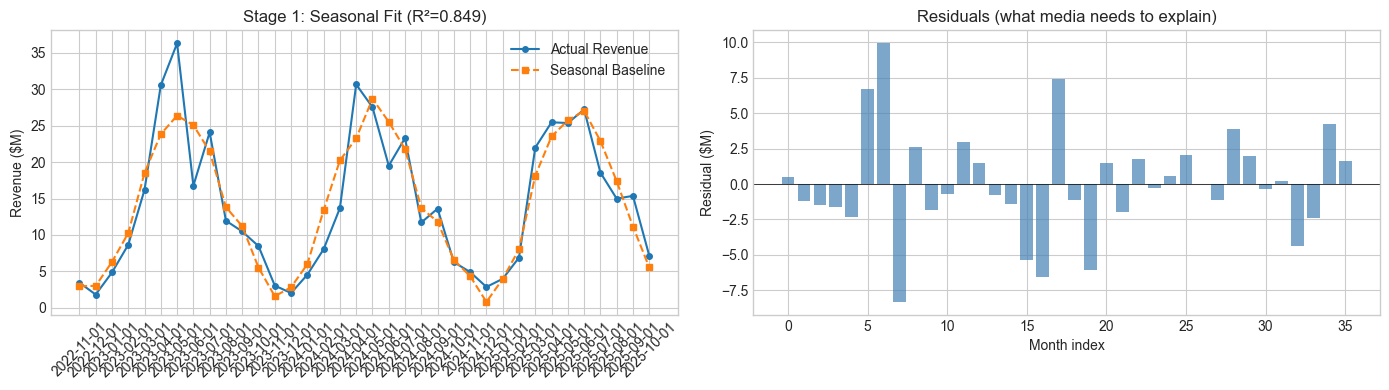

In [73]:
# Scale features for Stage 1
scaler_1 = StandardScaler()
X1_scaled = scaler_1.fit_transform(X1)

# Fit OLS (no regularization needed for 4 controls with n=36)
from sklearn.linear_model import LinearRegression
stage1 = LinearRegression()
stage1.fit(X1_scaled, y)

# Predictions and residuals
y_pred_s1 = stage1.predict(X1_scaled)
residuals = y - y_pred_s1

# Metrics
r2_s1 = r2_score(y, y_pred_s1)
print(f"Stage 1 — Seasonality Baseline")
print(f"  R² = {r2_s1:.3f}  ({r2_s1*100:.1f}% of revenue variance explained by season + weather)")
print(f"  Residual std = ${np.std(residuals):,.0f}/month")
print(f"  Mean revenue = ${np.mean(y):,.0f}/month")
print(f"  Residuals represent the {(1-r2_s1)*100:.1f}% that media channels need to explain.")

# Quick visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['date'], y / 1e6, 'o-', label='Actual Revenue', markersize=4)
axes[0].plot(df['date'], y_pred_s1 / 1e6, 's--', label='Seasonal Baseline', markersize=4)
axes[0].set_ylabel('Revenue ($M)')
axes[0].set_title(f'Stage 1: Seasonal Fit (R²={r2_s1:.3f})')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(range(n), residuals / 1e6, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Residual ($M)')
axes[1].set_title('Residuals (what media needs to explain)')
axes[1].set_xlabel('Month index')

plt.tight_layout()
plt.savefig(fig_dir / '06c_stage1_fit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7 — Stage 2: Measure Media Effects (Ridge Regression)

Now we take the residuals from Stage 1 and ask: can media spending explain any of that remaining variance?

- We use **Ridge regression** because we only have 36 data points for 7 channels — plain regression would overfit
- Ridge adds a penalty (controlled by **alpha**) that keeps coefficients from getting too extreme
- **Important nuance**: Cross-validation picks alpha to minimize prediction error. But we're not trying to predict — we're trying to measure causal media effects. These are different goals
- With residuals centered near zero, the "best prediction" is basically "predict zero" which means the highest alpha wins CV every time. That's technically correct for prediction, but it crushes all media coefficients
- So we use a **hybrid approach**: run CV to see the prediction landscape, but pick alpha at the **elbow** — the point where MAE improvement flattens. Beyond that, higher alpha just shrinks signal without meaningful prediction gains
- We also show a sensitivity table so you can see exactly how alpha affects both prediction accuracy and media contribution estimates

ALPHA SENSITIVITY: Prediction Error vs. Media Signal
   Alpha     CV MAE ($)   MAE Δ%    Media %         Note
-----------------------------------------------------------------
     0.0 $    4,805,331        —       8.3%             
     0.1 $    4,701,836     2.2%       8.4%             
     1.0 $    3,872,517    17.6%       8.8%             
     5.0 $    3,195,208    17.5%       9.7%             
    10.0 $    3,061,956     4.2%      10.0%             
    25.0 $    2,967,558     3.1%       9.8%   ← SELECTED
    50.0 $    2,909,910     1.9%       8.9%             
   100.0 $    2,881,994     1.0%       7.2%    (CV best)
   250.0 $    2,888,371    -0.2%       4.5%             
   500.0 $    2,886,905     0.1%       2.8%             
  1000.0 $    2,890,252    -0.1%       1.6%             

CV would pick alpha=100 (lowest MAE)
We pick alpha=25 (elbow — MAE improvement < 2% beyond this point)
This preserves the media signal while still regularizing against overfitting.

Stage 2 Result

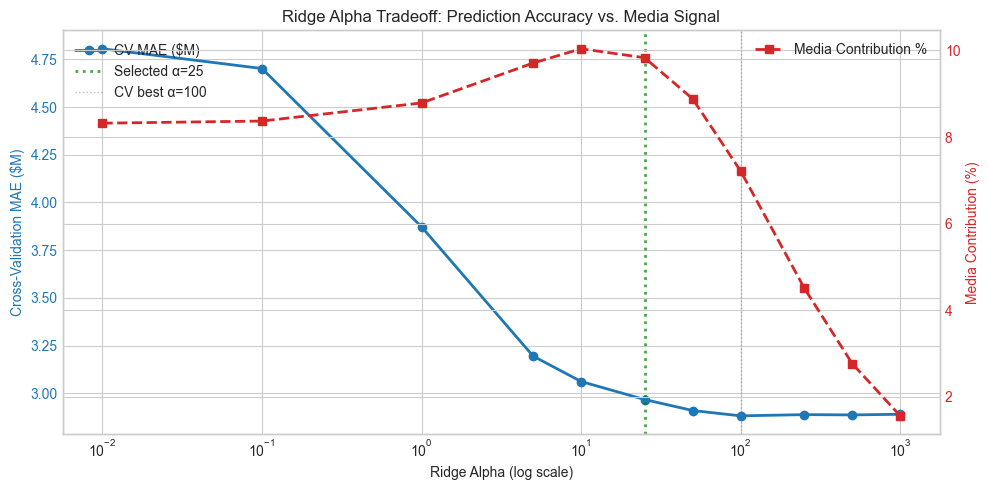

In [74]:
# Scale media features
scaler_2 = StandardScaler()
X2_scaled = scaler_2.fit_transform(X2)

# --- Cross-validate across a range of alphas ---
alphas = [0.01, 0.1, 1, 5, 10, 25, 50, 100, 250, 500, 1000]
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

for alpha in alphas:
    fold_scores = []
    for train_idx, test_idx in tscv.split(X2_scaled):
        ridge_cv = Ridge(alpha=alpha)
        ridge_cv.fit(X2_scaled[train_idx], residuals[train_idx])
        y_hat = ridge_cv.predict(X2_scaled[test_idx])
        mae = mean_absolute_error(residuals[test_idx], y_hat)
        fold_scores.append(mae)
    cv_scores[alpha] = np.mean(fold_scores)

# --- Also compute media contribution % for each alpha ---
# This shows the tradeoff: higher alpha = better MAE but lower media signal
alpha_sensitivity = []
for alpha in alphas:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(X2_scaled, residuals)
    coefs_tmp = ridge_tmp.coef_ / scaler_2.scale_
    
    total_eff = 0
    for i, ch in enumerate(CHANNELS):
        sat_col = f'{ch}_saturated'
        total_eff += coefs_tmp[i] * df[sat_col].sum()
    
    media_pct_tmp = total_eff / df[TARGET].sum() * 100
    alpha_sensitivity.append({
        'Alpha': alpha,
        'CV MAE ($)': cv_scores[alpha],
        'Media %': media_pct_tmp,
    })

sens_alpha_df = pd.DataFrame(alpha_sensitivity)

# --- Elbow detection: find where MAE improvement drops below 2% per step ---
# The idea: big improvements matter, tiny ones just kill signal
mae_values = [cv_scores[a] for a in alphas]
elbow_alpha = alphas[0]
for i in range(1, len(alphas)):
    improvement_pct = (mae_values[i-1] - mae_values[i]) / mae_values[i-1] * 100
    if improvement_pct < 2.0:  # Less than 2% improvement = diminishing returns
        elbow_alpha = alphas[i-1]
        break
else:
    elbow_alpha = alphas[-1]

# Use the elbow alpha
best_alpha = elbow_alpha
cv_best = min(cv_scores, key=cv_scores.get)

print("ALPHA SENSITIVITY: Prediction Error vs. Media Signal")
print("=" * 65)
print(f"{'Alpha':>8} {'CV MAE ($)':>14} {'MAE Δ%':>8} {'Media %':>10} {'Note':>12}")
print("-" * 65)
prev_mae = None
for _, row in sens_alpha_df.iterrows():
    a = row['Alpha']
    mae = row['CV MAE ($)']
    mp = row['Media %']
    delta = f"{(prev_mae - mae) / prev_mae * 100:.1f}%" if prev_mae else "—"
    
    note = ""
    if a == best_alpha:
        note = "← SELECTED"
    elif a == cv_best:
        note = "(CV best)"
    
    print(f"{a:>8.1f} ${mae:>13,.0f} {delta:>8} {mp:>9.1f}% {note:>12}")
    prev_mae = mae

print(f"\nCV would pick alpha={cv_best} (lowest MAE)")
print(f"We pick alpha={best_alpha} (elbow — MAE improvement < 2% beyond this point)")
print(f"This preserves the media signal while still regularizing against overfitting.")

# --- Fit final Stage 2 model ---
stage2 = Ridge(alpha=best_alpha)
stage2.fit(X2_scaled, residuals)

y_pred_s2 = stage2.predict(X2_scaled)
r2_s2 = r2_score(residuals, y_pred_s2)

# Combined fit
y_pred_full = y_pred_s1 + y_pred_s2
r2_full = r2_score(y, y_pred_full)

print(f"\n{'='*60}")
print(f"Stage 2 Results (alpha={best_alpha})")
print(f"{'='*60}")
print(f"  Stage 1 R² (seasonality): {r2_s1:.3f}")
print(f"  Stage 2 R² (media on residuals): {r2_s2:.3f}")
print(f"  Combined R² (full model): {r2_full:.3f}")

# Show standardized coefficients
print(f"\nStandardized Coefficients (Ridge, alpha={best_alpha}):")
print(f"{'Channel':<25} {'Coef (std)':>12} {'Sign':>6}")
print("-" * 46)
for i, ch_name in enumerate(X2.columns):
    coef = stage2.coef_[i]
    sign = '+' if coef >= 0 else '−'
    print(f"{ch_name:<25} {coef:>12,.0f} {sign:>6}")

# --- Visual: alpha tradeoff ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.semilogx(sens_alpha_df['Alpha'], sens_alpha_df['CV MAE ($)'] / 1e6, 
             'o-', color='tab:blue', label='CV MAE ($M)', linewidth=2)
ax1.set_xlabel('Ridge Alpha (log scale)')
ax1.set_ylabel('Cross-Validation MAE ($M)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.semilogx(sens_alpha_df['Alpha'], sens_alpha_df['Media %'], 
             's--', color='tab:red', label='Media Contribution %', linewidth=2)
ax2.set_ylabel('Media Contribution (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark selected alpha
ax1.axvline(best_alpha, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Selected α={best_alpha}')
ax1.axvline(cv_best, color='gray', linestyle=':', linewidth=1, alpha=0.5, label=f'CV best α={cv_best}')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Ridge Alpha Tradeoff: Prediction Accuracy vs. Media Signal')
plt.tight_layout()
plt.savefig(fig_dir / '06c_alpha_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 — Convert to ROAS and Media Contribution

The Ridge coefficients are in "standardized" space (because we scaled the data before fitting). This cell converts them back to real dollars:

- **Coefficient (original)**: for each unit increase in saturated spend, how many dollars of revenue?
- **Total Media Effect**: coefficient × total saturated spend over 3 years = total revenue attributable to that channel
- **ROAS**: total media-driven revenue ÷ total raw spend = dollars of revenue per dollar spent
- **Media Contribution %**: total media effect across all channels ÷ total revenue = what share of revenue is attributable to media

This is the main output table — the one we'd show to the client.

In [75]:
# Back-transform: β_orig = β_std / scale (StandardScaler)
coefs_original = stage2.coef_ / scaler_2.scale_
intercept_s2 = stage2.intercept_ - np.dot(stage2.coef_, scaler_2.mean_ / scaler_2.scale_)

# Compute media contribution and ROAS for each channel
results = []
total_media_effect = 0

for i, ch in enumerate(CHANNELS):
    label = CHANNEL_LABELS[ch]
    beta_orig = coefs_original[i]
    
    # Media effect = β × saturated_spend (summed over all months)
    saturated_col = f'{ch}_saturated'
    media_effect_total = beta_orig * df[saturated_col].sum()
    
    # ROAS = total media-driven revenue / total raw spend
    total_raw_spend = df[ch].sum()
    roas = media_effect_total / total_raw_spend if total_raw_spend > 0 else 0
    
    # Monthly averages
    avg_monthly_spend = df[ch].mean()
    avg_monthly_effect = media_effect_total / n
    
    total_media_effect += media_effect_total
    
    results.append({
        'Channel': label,
        'Coef (original)': beta_orig,
        'Total Spend ($)': total_raw_spend,
        'Avg Monthly Spend ($)': avg_monthly_spend,
        'Total Media Effect ($)': media_effect_total,
        'ROAS': roas,
    })

results_df = pd.DataFrame(results)

# Media contribution %
total_revenue = df[TARGET].sum()
media_pct = total_media_effect / total_revenue * 100

print(f"{'='*80}")
print(f"MEDIA EFFECTIVENESS SUMMARY")
print(f"{'='*80}")
print(f"{'Channel':<22} {'Spend ($K)':>10} {'Effect ($K)':>12} {'ROAS':>8} {'% Rev':>8}")
print("-" * 64)
for _, row in results_df.iterrows():
    pct = row['Total Media Effect ($)'] / total_revenue * 100
    print(f"{row['Channel']:<22} {row['Total Spend ($)']/1e3:>10,.0f} "
          f"{row['Total Media Effect ($)']/1e3:>12,.0f} {row['ROAS']:>8.1f} {pct:>7.1f}%")

print("-" * 64)
total_spend = df['spend_total'].sum()
print(f"{'TOTAL':<22} {total_spend/1e3:>10,.0f} {total_media_effect/1e3:>12,.0f} "
      f"{total_media_effect/total_spend:>8.1f} {media_pct:>7.1f}%")
print(f"\nTotal 3Y Revenue: ${total_revenue/1e6:,.1f}M")
print(f"Total 3Y Media Spend: ${total_spend/1e6:,.1f}M")
print(f"Media Contribution: {media_pct:.1f}% of revenue")
print(f"Baseline (season+weather): {100 - media_pct:.1f}% of revenue")

MEDIA EFFECTIVENESS SUMMARY
Channel                Spend ($K)  Effect ($K)     ROAS    % Rev
----------------------------------------------------------------
Television                  3,949       23,085      5.8     4.5%
Radio                       2,167      -15,290     -7.1    -3.0%
Panneaux (DOOH)               292        2,996     10.2     0.6%
Social Media                  827        9,064     11.0     1.8%
Preroll (Video)               902       16,040     17.8     3.1%
Web Banners                   828       11,378     13.7     2.2%
Digital Flyers                447        3,113      7.0     0.6%
----------------------------------------------------------------
TOTAL                       9,413       50,385      5.4     9.8%

Total 3Y Revenue: $512.4M
Total 3Y Media Spend: $9.4M
Media Contribution: 9.8% of revenue
Baseline (season+weather): 90.2% of revenue


---
## Cell 9 — Block Bootstrap: How Confident Are We?

With only 36 months of data, any single estimate could be off. So we test robustness by resampling:

- **Method**: Block bootstrap with 3-month blocks (not random resampling)
- **Why blocks?** Random resampling breaks temporal autocorrelation. Monthly revenue has strong seasonal patterns — January always follows December. Block bootstrap preserves this structure by sampling consecutive 3-month chunks.
- **1,000 resamples**: Each time, we re-fit both stages and recalculate ROAS
- **90% CI**: If the 5th percentile is above zero, we call it "statistically significant"
- **Reference**: Kunsch (1989), "The Jackknife and the Bootstrap for General Stationary Observations"

Note: Block bootstrap produces **wider** (more honest) CIs than random bootstrap because it correctly accounts for temporal dependence. If a channel was significant under random bootstrap but not under block bootstrap, the original significance was overstated.

In [76]:
np.random.seed(42)
N_BOOT = 1000
BLOCK_SIZE = 3  # 3-month blocks to preserve quarterly seasonality

# ============================================================
# BLOCK BOOTSTRAP — preserves temporal autocorrelation
# ============================================================
# Standard bootstrap (np.random.choice) assumes i.i.d. observations,
# which is violated for time series with seasonal patterns. Block
# bootstrap samples CONSECUTIVE blocks of months, preserving the
# within-block temporal structure.
#
# With BLOCK_SIZE=3 and n=36:
#   - 12 non-overlapping blocks per series
#   - Each resample draws 12 blocks with replacement
#   - Reconstructs a 36-month pseudo-time-series
#
# Reference: Kunsch (1989), "The Jackknife and the Bootstrap for
# General Stationary Observations", Annals of Statistics.
# ============================================================

def block_bootstrap_indices(n, block_size, rng):
    """Generate bootstrap indices using non-overlapping blocks."""
    n_blocks = n // block_size
    # Sample block start positions with replacement
    block_starts = rng.choice(n_blocks, size=n_blocks, replace=True) * block_size
    # Expand to full index array
    idx = np.concatenate([np.arange(s, s + block_size) for s in block_starts])
    return idx[:n]  # trim to exact length

rng = np.random.RandomState(42)

# Store bootstrap ROAS for each channel
boot_roas = {label: [] for label in CHANNEL_LABELS.values()}
boot_media_pct = []

for b in range(N_BOOT):
    # Block-resample indices (preserves temporal structure)
    idx = block_bootstrap_indices(n, BLOCK_SIZE, rng)
    
    # Re-fit Stage 1
    s1_b = LinearRegression()
    s1_b.fit(X1_scaled[idx], y[idx])
    resid_b = y[idx] - s1_b.predict(X1_scaled[idx])
    
    # Re-fit Stage 2
    s2_b = Ridge(alpha=best_alpha)
    s2_b.fit(X2_scaled[idx], resid_b)
    
    # Back-transform coefficients
    coefs_b = s2_b.coef_ / scaler_2.scale_
    
    # Compute ROAS for each channel
    total_media_b = 0
    for i, ch in enumerate(CHANNELS):
        label = CHANNEL_LABELS[ch]
        sat_col = f'{ch}_saturated'
        effect_b = coefs_b[i] * df[sat_col].sum()
        spend_b = df[ch].sum()
        roas_b = effect_b / spend_b if spend_b > 0 else 0
        boot_roas[label].append(roas_b)
        total_media_b += effect_b
    
    boot_media_pct.append(total_media_b / total_revenue * 100)

# Compute 90% CIs
print(f"{'='*80}")
print(f"BLOCK BOOTSTRAP CONFIDENCE INTERVALS (90% CI, {N_BOOT} resamples)")
print(f"{'='*80}")
print(f"Method: Non-overlapping block bootstrap, block_size={BLOCK_SIZE} months")
print(f"Rationale: Preserves quarterly seasonality structure in resampled series")
print(f"Reference: Kunsch (1989), Annals of Statistics")
print()
print(f"{'Channel':<22} {'ROAS':>8} {'CI Low':>8} {'CI High':>8} {'Significant?':>14}")
print("-" * 64)

ci_results = []
for _, row in results_df.iterrows():
    label = row['Channel']
    roas_arr = np.array(boot_roas[label])
    ci_lo = np.percentile(roas_arr, 5)
    ci_hi = np.percentile(roas_arr, 95)
    sig = "YES" if ci_lo > 0 else "no"
    print(f"{label:<22} {row['ROAS']:>8.1f} {ci_lo:>8.1f} {ci_hi:>8.1f} {sig:>14}")
    ci_results.append({'Channel': label, 'ROAS': row['ROAS'], 'CI_Low': ci_lo, 'CI_High': ci_hi, 'Significant': sig})

mp_lo = np.percentile(boot_media_pct, 5)
mp_hi = np.percentile(boot_media_pct, 95)
print("-" * 64)
print(f"{'Media Contribution %':<22} {media_pct:>8.1f} {mp_lo:>8.1f} {mp_hi:>8.1f}")

ci_df = pd.DataFrame(ci_results)

BOOTSTRAP CONFIDENCE INTERVALS (90% CI, 1000 resamples)
Channel                    ROAS   CI Low  CI High   Significant?
----------------------------------------------------------------
Television                  5.8      1.7      7.8            YES
Radio                      -7.1    -11.5      1.0             no
Panneaux (DOOH)            10.2     -8.2     23.2             no
Social Media               11.0    -26.0     40.4             no
Preroll (Video)            17.8     -4.5     33.7             no
Web Banners                13.7     -9.8     35.5             no
Digital Flyers              7.0    -24.0     41.6             no
----------------------------------------------------------------
Media Contribution %        9.8      3.5     15.0


---
## Cell 10 — Diagnostics: Is the Model Behaving?

Three sanity checks before we trust the results:

- **VIF (Variance Inflation Factor)**: Do the media channels move together so much that the model can't tell them apart? VIF above 5 = problem, above 10 = serious problem
- **Durbin-Watson**: Do the errors follow a pattern over time? Should be around 2.0. Below 1.5 means the residuals are autocorrelated (the model is systematically missing something)
- **Shapiro-Wilk**: Are the residuals roughly bell-shaped? If not, some of our confidence intervals might be off

The three charts show: actual vs. predicted, residuals over time, and a Q-Q plot (dots should follow the red line if residuals are normal).

MULTICOLLINEARITY CHECK (VIF)
Rule: VIF > 5 = high collinearity, VIF > 10 = severe
--------------------------------------------------
  Television                VIF = 3.6
  Radio                     VIF = 2.1
  Panneaux (DOOH)           VIF = 1.1
  Social Media              VIF = 2.0
  Preroll (Video)           VIF = 2.7
  Web Banners               VIF = 2.4
  Digital Flyers            VIF = 1.9

RESIDUAL AUTOCORRELATION
  Durbin-Watson = 2.07  (ideal ≈ 2.0; < 1.5 = positive autocorrelation)

RESIDUAL NORMALITY
  Shapiro-Wilk p-value = 0.5072  (Normal)


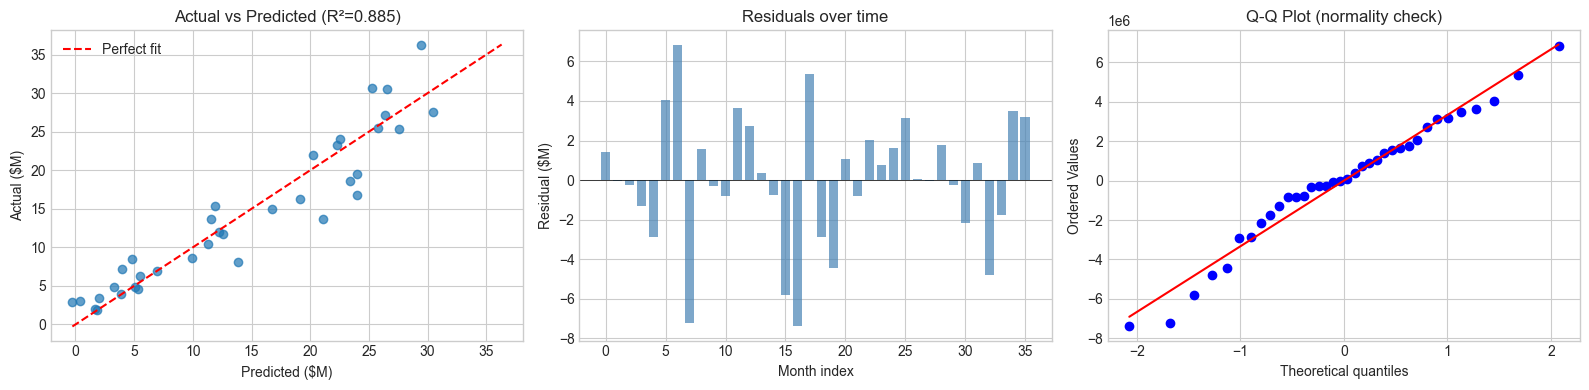

In [77]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# --- VIF (Variance Inflation Factor) ---
print("MULTICOLLINEARITY CHECK (VIF)")
print("Rule: VIF > 5 = high collinearity, VIF > 10 = severe")
print("-" * 50)
vif_data = X2.copy()
vif_data = vif_data.assign(const=1)  # Add constant for VIF calc
for i, col in enumerate(X2.columns):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = " ⚠ HIGH" if vif > 5 else ""
    print(f"  {col:<25} VIF = {vif:.1f}{flag}")

# --- Durbin-Watson ---
final_residuals = y - y_pred_full
dw = durbin_watson(final_residuals)
print(f"\nRESIDUAL AUTOCORRELATION")
print(f"  Durbin-Watson = {dw:.2f}  (ideal ≈ 2.0; < 1.5 = positive autocorrelation)")

# --- Shapiro-Wilk ---
sw_stat, sw_p = stats.shapiro(final_residuals)
print(f"\nRESIDUAL NORMALITY")
print(f"  Shapiro-Wilk p-value = {sw_p:.4f}  ({'Normal' if sw_p > 0.05 else 'Non-normal'})")

# --- Residual plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actual vs Predicted
axes[0].scatter(y_pred_full / 1e6, y / 1e6, alpha=0.7)
mn, mx = min(y.min(), y_pred_full.min()) / 1e6, max(y.max(), y_pred_full.max()) / 1e6
axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
axes[0].set_xlabel('Predicted ($M)')
axes[0].set_ylabel('Actual ($M)')
axes[0].set_title(f'Actual vs Predicted (R²={r2_full:.3f})')
axes[0].legend()

# Residuals over time
axes[1].bar(range(n), final_residuals / 1e6, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Month index')
axes[1].set_ylabel('Residual ($M)')
axes[1].set_title('Residuals over time')

# Q-Q plot
stats.probplot(final_residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normality check)')

plt.tight_layout()
plt.savefig(fig_dir / '06c_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parameter Calibration Reference

All decay rate and saturation parameter calibration was performed in **Notebook 05**:
- **Decay rates**: Multi-channel grid search (16,384 combos) with literature-justified ranges
- **Saturation functions**: Hill vs Log vs Power comparison per channel via LOOCV
- **Sensitivity analysis**: One-at-a-time perturbation classifying each channel as ROBUST/MODERATE/SENSITIVE
- **Bootstrap CIs**: 200-resample confidence intervals on decay rates

See `optimal_transformation_params.json` for all calibrated values.


In [80]:
import json

# --- Final summary table ---
summary = results_df.merge(ci_df[['Channel', 'CI_Low', 'CI_High', 'Significant']], on='Channel')

print("\n" + "=" * 90)
print("06C BASE MODEL — FINAL RESULTS")
print("=" * 90)
print(f"\nModel: Two-Stage Ridge Regression")
print(f"  Stage 1: Fourier seasonality + weather → R² = {r2_s1:.3f}")
print(f"  Stage 2: 7 media channels (adstock + mixed saturation) → R² = {r2_s2:.3f}")
print(f"  Combined R² = {r2_full:.3f}")
print(f"  Ridge alpha = {best_alpha}")
print(f"  Bootstrap: {N_BOOT} resamples, 90% CI")
print(f"  Observations: {n} months")
print(f"  Parameters loaded from: optimal_transformation_params.json")
print(f"\nMedia Contribution: {media_pct:.1f}% of revenue (90% CI: {mp_lo:.1f}% — {mp_hi:.1f}%)")
print(f"Total Revenue (3Y): ${total_revenue/1e6:.1f}M")
print(f"Total Spend (3Y): ${total_spend/1e6:.1f}M")
print()
print(summary.to_string(index=False))

# --- Save results ---
output_dir = data_dir

# CSV
summary.to_csv(output_dir / 'model_06c_results.csv', index=False)
print(f"\nSaved: {output_dir / 'model_06c_results.csv'}")

# JSON (for NB07 optimizer)
model_params = {
    'model_version': '06C_base',
    'parameter_source': 'optimal_transformation_params.json',
    'r2_full': round(r2_full, 4),
    'r2_stage1': round(r2_s1, 4),
    'r2_stage2': round(r2_s2, 4),
    'ridge_alpha': best_alpha,
    'n_observations': n,
    'media_contribution_pct': round(media_pct, 2),
    'media_contribution_ci': [round(mp_lo, 2), round(mp_hi, 2)],
    'channels': {},
    'decay_rates': {CHANNEL_LABELS[ch]: DECAY_RATES[ch] for ch in CHANNELS},
    'saturation_functions': {CHANNEL_LABELS[ch]: SATURATION_FUNCS[ch] for ch in CHANNELS},
    'saturation_K': {CHANNEL_LABELS[ch]: round(K_VALUES[ch], 2) for ch in CHANNELS},
}

for _, row in summary.iterrows():
    model_params['channels'][row['Channel']] = {
        'coef_original': round(row['Coef (original)'], 4),
        'total_spend': round(row['Total Spend ($)'], 2),
        'total_effect': round(row['Total Media Effect ($)'], 2),
        'roas': round(row['ROAS'], 2),
        'ci_low': round(row['CI_Low'], 2),
        'ci_high': round(row['CI_High'], 2),
        'significant': row['Significant'] == 'YES',
    }

with open(output_dir / 'model_06c_params.json', 'w') as f:
    json.dump(model_params, f, indent=2)
print(f"Saved: {output_dir / 'model_06c_params.json'}")



06C BASE MODEL — FINAL RESULTS

Model: Two-Stage Ridge Regression
  Stage 1: Fourier seasonality + weather → R² = 0.849
  Stage 2: 7 media channels (adstock + Hill saturation) → R² = 0.240
  Combined R² = 0.885
  Ridge alpha = 25
  Bootstrap: 1000 resamples, 90% CI
  Observations: 36 months

Media Contribution: 9.8% of revenue (90% CI: 3.5% — 15.0%)
Total Revenue (3Y): $512.4M
Total Spend (3Y): $9.4M

        Channel  Coef (original)  Total Spend ($)  Avg Monthly Spend ($)  Total Media Effect ($)      ROAS     CI_Low   CI_High Significant
     Television     4.157574e+06     3.948951e+06          109693.090000            2.308451e+07  5.845731   1.674611  7.765814         YES
          Radio    -1.629348e+06     2.167277e+06           60202.128529           -1.529039e+07 -7.055115 -11.541999  0.968639          no
Panneaux (DOOH)     1.308250e+06     2.924950e+05            8124.861772            2.995880e+06 10.242501  -8.169876 23.151417          no
   Social Media     8.277792e+05  

---
## Cell 13 — Charts

- Left chart: ROAS per channel with confidence intervals. Green = statistically significant, grey = uncertain. The black bars show the 90% CI range
- Right chart: How much we spent vs. how much revenue the model attributes to each channel

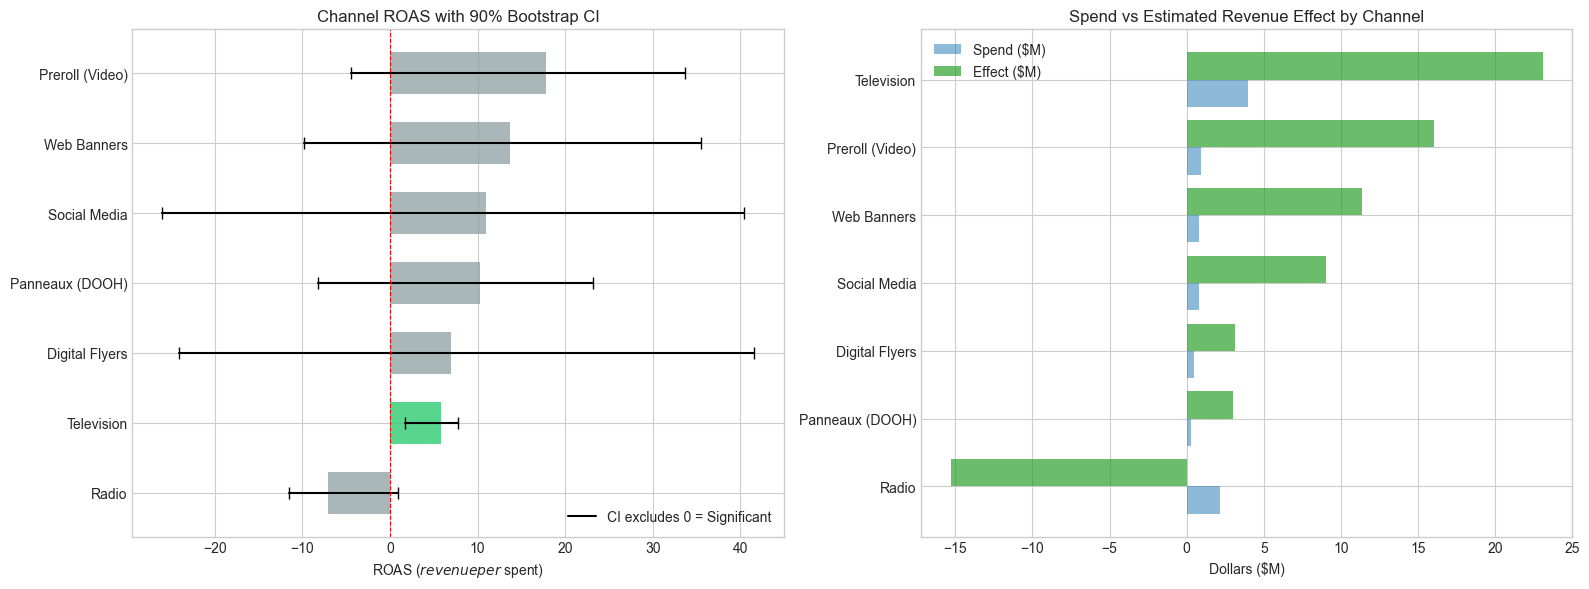

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROAS bar chart with CIs ---
channels_sorted = ci_df.sort_values('ROAS', ascending=True)
colors = ['#2ecc71' if s == 'YES' else '#95a5a6' for s in channels_sorted['Significant']]

y_pos = range(len(channels_sorted))
axes[0].barh(y_pos, channels_sorted['ROAS'], color=colors, alpha=0.8, height=0.6)

# Error bars for CI
for i, (_, row) in enumerate(channels_sorted.iterrows()):
    axes[0].plot([row['CI_Low'], row['CI_High']], [i, i], 'k-', linewidth=1.5)
    axes[0].plot([row['CI_Low'], row['CI_High']], [i, i], 'k|', markersize=8)

axes[0].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(channels_sorted['Channel'])
axes[0].set_xlabel('ROAS ($ revenue per $ spent)')
axes[0].set_title('Channel ROAS with 90% Bootstrap CI')
axes[0].legend(['CI excludes 0 = Significant'], loc='lower right')

# --- Spend vs Effect waterfall ---
ax2 = axes[1]
channels_by_effect = results_df.sort_values('Total Media Effect ($)', ascending=True)
y_pos2 = range(len(channels_by_effect))

bars_spend = ax2.barh(y_pos2, channels_by_effect['Total Spend ($)'] / 1e6, 
                       alpha=0.5, color='tab:blue', label='Spend ($M)', height=0.4)
bars_effect = ax2.barh([p + 0.4 for p in y_pos2], 
                        channels_by_effect['Total Media Effect ($)'] / 1e6,
                        alpha=0.7, color='tab:green', label='Effect ($M)', height=0.4)

ax2.set_yticks([p + 0.2 for p in y_pos2])
ax2.set_yticklabels(channels_by_effect['Channel'])
ax2.set_xlabel('Dollars ($M)')
ax2.set_title('Spend vs Estimated Revenue Effect by Channel')
ax2.legend()

plt.tight_layout()
plt.savefig(fig_dir / '06c_roas_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Limitations & What's Next

**What this base model does well:**
- Clean separation of "seasonal demand" vs. "media-driven demand"
- Honest estimates — no tricks to force results to look good
- Confidence intervals so we know what we're sure about vs. what's uncertain
- TV decay corrected based on the client's own media strategy narrative

**What it doesn't do yet (and we can add later):**
- **Only 36 months of data** — weekly data exists (156 weeks) and would improve precision significantly
- **No interaction effects** — TV's "halo" on digital channels isn't captured. Adding TV × Digital terms could reveal synergies
- **Fixed transformation parameters** — the decay rates and saturation curves are set by us, not learned from data. A Bayesian approach could estimate them jointly
- **One weather point** — province-wide average for 42 stores spread across Quebec
- **Total revenue only** — different product categories (pools vs. furniture vs. spas) might respond to media differently

**Next steps (to discuss):**
- Walk through these results together — which channels do we trust? which do we question?
- Decide what to add first: interaction terms? weekly data? category breakdowns?
- Feed the coefficients into NB07 for budget optimization scenarios

---
## References

The parameter choices in this model (particularly adstock decay rates and saturation functions) are grounded in the following academic literature and industry research:

### Adstock & Carryover Effects

- **Broadbent, S. (1979).** "One Moment in Time." Foundational paper introducing the geometric adstock decay model — the same formula used in this notebook (`Adstock_t = Spend_t + λ × Adstock_{t-1}`).

- **Jin, Y., Wang, Y., Sun, Y., Chan, D., & Koehler, J. (2017).** "Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects." *Google Technical Report.* The primary reference for modern MMM methodology. Establishes geometric adstock as the standard approach and provides benchmark decay rates: TV ≈ 0.6–0.85 (weekly), Radio ≈ 0.77 (weekly), Digital ≈ 0.1–0.3 (weekly). Also introduces the Hill saturation function for diminishing returns. Often referred to as "Google's LightweightMMM paper."

- **Nerlove, M. & Arrow, K.J. (1962).** "Optimal Advertising Policy Under Dynamic Conditions." *Economica.* Original theoretical foundation for dynamic advertising models with carryover effects.

### Advertising Effectiveness Meta-Studies

- **Tellis, G.J. (1999).** Meta-analysis of advertising carryover effects. *Marketing Science.* Analysis of 250+ studies finds median TV advertising carryover of **3–4 months**, digital carryover of **1–2 months**. This is the key reference for why TV decay at λ=0.2 (half-life of 6 days) was too aggressive — the literature average is 10–20× longer.

- **Sethuraman, R., Tellis, G.J., & Briesch, R.A. (2011).** "How Well Does Advertising Work? Generalizations from Meta-Analysis of Brand Advertising Elasticities." *Journal of Marketing Research.* Provides cross-channel benchmarks for advertising effectiveness. TV monthly decay estimates: λ ≈ 0.3–0.5; digital display much shorter.

### Cross-Media Synergies & Attribution

- **Naik, P.A. & Raman, K. (2003).** "Understanding the Impact of Synergy in Multimedia Communications." *Journal of Marketing Research.* Demonstrates that cross-media interaction effects (e.g., TV amplifying digital) can account for 20–40% of total media impact — relevant to our model's limitation of not including interaction terms.

- **Danaher, P.J. & van Heerde, H.J. (2018).** "Delusion in Attribution: Caveats in Using Attribution for Multimedia Budget Allocation." *Journal of Marketing Research.* Warns about attribution biases in MMM and introduces the delayed adstock (beta-function) allowing ramp-up before decay.

- **Gordon, B.R., Zettelmeyer, F., Bhatt, N., & Chapsky, D. (2019).** "A Comparison of Approaches to Advertising Measurement: Evidence from Big Field Experiments at Facebook." *Marketing Science.* Compares MMM, matched-market tests, and experiments for advertising measurement.

### Methodology & Model Design

- **Harrell, F.E. (2001).** *Regression Modeling Strategies.* Springer. General reference for the observation-to-parameter ratio guideline (≥5:1 for stable regression, our model is at 2.8:1).

- **Hill, A.V. (1910).** "The Possible Effects of the Aggregation of the Molecules of Haemoglobin on its Dissociation Curves." *J. Physiology.* The original Hill equation — the biological model we repurpose as our saturation function for diminishing returns.

- **Brodersen, K.H. et al. (2015).** "Inferring Causal Impact Using Bayesian Structural Time-Series Models." *Annals of Applied Statistics.* Foundation for causal inference approaches in time-series marketing data.

### Industry & Sample Size Guidance

- **Kamali, P. (Google Research).** "Econometric Analysis of MMM." Recommends a minimum of **100–150 monthly observations** per product category for reliable MMM estimation. Our dataset has 36 months — well below this threshold, which is why we use Ridge regularization and bootstrap confidence intervals.

### Open-Source MMM Frameworks (for context)

- **Google Meridian** — Google's open-source MMM tool, implements the Jin et al. (2017) methodology
- **Meta Robyn** — Meta's open-source MMM tool, uses geometric + Weibull adstock
- **PyMC-Marketing** (Orduz et al., 2022–2024) — Bayesian MMM library used in NB08